# Neural Networks for Binary Classification: Pima Indians Diabetes Prediction

## Overview
Build a neural network to predict diabetes from clinical measurements. Expected accuracy: **70-75%** on test data.

## Dataset Information
- **Source**: Kaggle
- **Samples**: 768 patients
- **Features**: 8 clinical measurements (pregnancies, glucose, blood pressure, skin thickness, insulin, BMI, diabetes pedigree, age)
- **Target**: Diabetes (0 = No, 1 = Yes)
- **Challenge**: Class imbalance (65% no diabetes, 35% diabetes)

## 1. Import Libraries

Set random seeds for reproducibility and import all necessary libraries for data processing, modeling, and visualization.

In [13]:
import numpy as np
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

print(" All libraries imported successfully!")

 All libraries imported successfully!


## 2. Load Pima Indians Diabetes Dataset

**Source**: Kaggle  
**Samples**: 768 patients  
**Features**: 8 clinical measurements  
**Classes**: Diabetes (0/1)  
**Challenge**: Class imbalance (65/35 split)

In [2]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"

print("Loading Pima Indians Diabetes dataset ...")
data = pd.read_csv(url)

# Clean data — replace biologically impossible zeros with column median
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    data[col] = data[col].replace(0, data[col].median())

print("✓ Replaced impossible zero values with column medians")
print(f"  (Glucose, BloodPressure, SkinThickness, Insulin, BMI cannot be 0)")


X = data.drop('Outcome', axis=1).values
y = data['Outcome'].values

feature_names = list(data.drop('Outcome', axis=1).columns)
target_names = ['No Diabetes', 'Diabetes']

print(f"✓ Dataset loaded successfully!")
print(f"Total samples: {X.shape[0]}")
print(f"Total features: {X.shape[1]}")
print(f"Feature names: {feature_names}")
print(f"\nClass Distribution:")
print(f"  No Diabetes (0): {np.sum(y == 0)} samples ({100*np.sum(y==0)/len(y):.1f}%)")
print(f"  Diabetes (1):    {np.sum(y == 1)} samples ({100*np.sum(y==1)/len(y):.1f}%)")

Loading Pima Indians Diabetes dataset ...
✓ Replaced impossible zero values with column medians
  (Glucose, BloodPressure, SkinThickness, Insulin, BMI cannot be 0)
✓ Dataset loaded successfully!
Total samples: 768
Total features: 8
Feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Class Distribution:
  No Diabetes (0): 500 samples (65.1%)
  Diabetes (1):    268 samples (34.9%)


## 3. Exploratory Data Analysis


Examine feature distributions, statistics, and patterns to understand the dataset characteristics and differences between diabetic and non-diabetic patients.

DATASET EXPLORATION

Feature Statistics after cleaning:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   121.66          72.39          27.33    94.65   32.45   
std           3.37    30.44          12.10           9.23   105.55    6.88   
min           0.00    44.00          24.00           7.00    14.00   18.20   
25%           1.00    99.75          64.00          23.00    30.50   27.50   
50%           3.00   117.00          72.00          23.00    31.25   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.47   33.24     0.35  
std                        0.33   11.76     0.48  
min                        0.08   21.

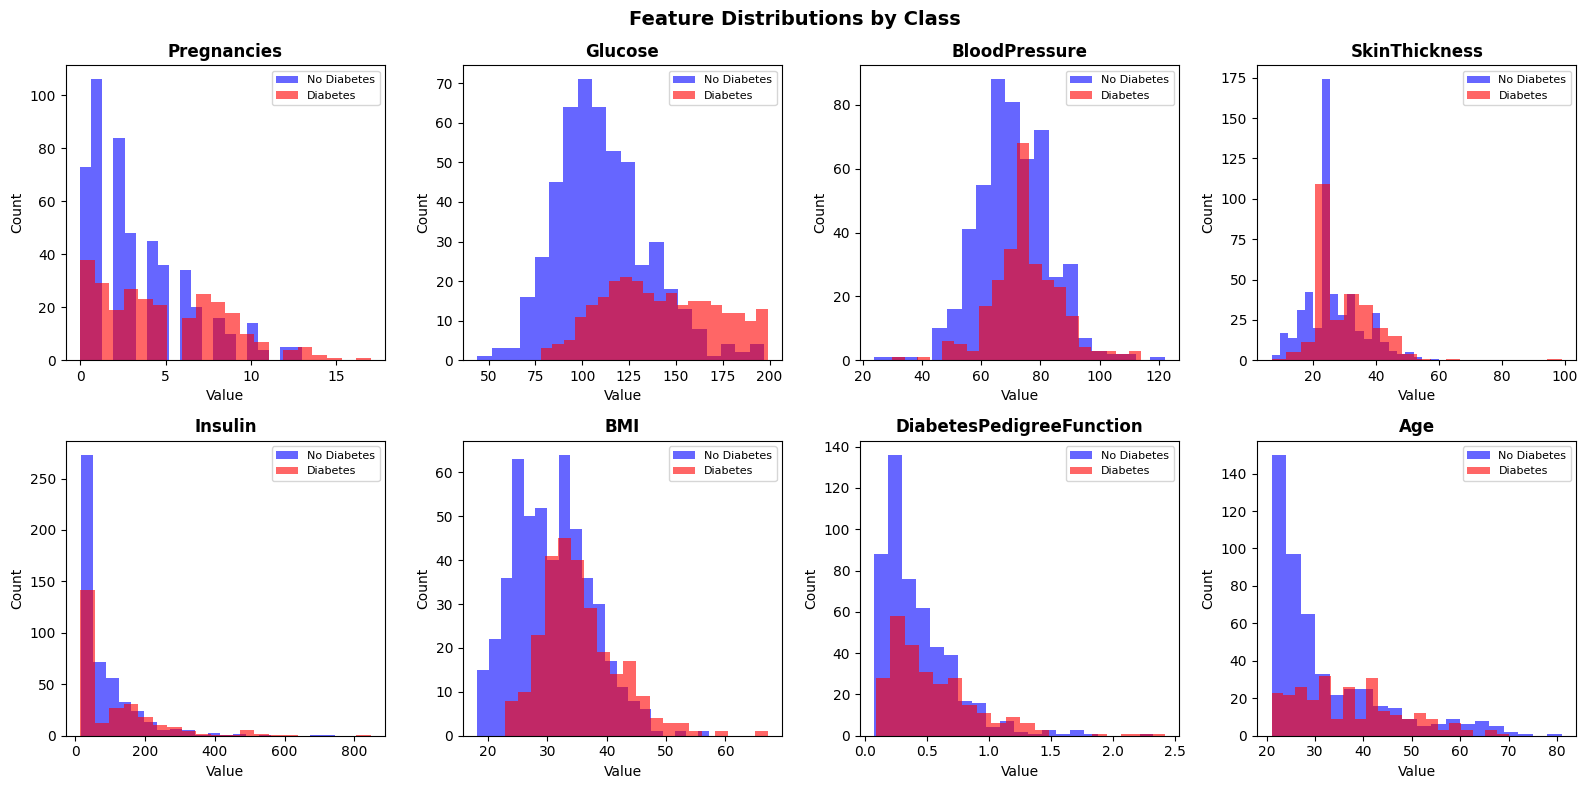

✓ Data exploration complete!


In [3]:
# Data Exploration
print("=" * 60)
print("DATASET EXPLORATION")
print("=" * 60)

print(f"\nFeature Statistics after cleaning:")
print(data.describe().round(2))

print(f"\nFeature Value Ranges:")
for col in feature_names:
    print(f"  {col}: min={data[col].min():.1f}, max={data[col].max():.1f}, mean={data[col].mean():.1f}")

# Plot feature distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(feature_names):
    axes[i].hist(data[data['Outcome']==0][col], alpha=0.6, label='No Diabetes', color='blue', bins=20)
    axes[i].hist(data[data['Outcome']==1][col], alpha=0.6, label='Diabetes', color='red', bins=20)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Data exploration complete!")

## 4. Data Preprocessing

**Steps**:
1. Split data: 80% training, 20% testing (stratified to maintain class balance)
2. Scale features to mean=0, std=1 using StandardScaler
3. Fit scaler only on training data to prevent data leakage

In [4]:
# Split data 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps 65/35 ratio in both splits
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(f"  No Diabetes: {np.sum(y_train == 0)} ({100*np.sum(y_train==0)/len(y_train):.1f}%)")
print(f"  Diabetes:    {np.sum(y_train == 1)} ({100*np.sum(y_train==1)/len(y_train):.1f}%)")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on training data
X_test_scaled  = scaler.transform(X_test)         # ONLY transform on test data

print(f"\nAfter Scaling:")
print(f"  Training mean: {X_train_scaled.mean(axis=0)[:3].round(4)} (should be ~0)")
print(f"  Training std:  {X_train_scaled.std(axis=0)[:3].round(4)} (should be ~1)")
print(f"\n✓ Preprocessing complete!")

Training set size: 614 samples
Testing set size:  154 samples

Training class distribution:
  No Diabetes: 400 (65.1%)
  Diabetes:    214 (34.9%)

After Scaling:
  Training mean: [-0. -0.  0.] (should be ~0)
  Training std:  [1. 1. 1.] (should be ~1)

✓ Preprocessing complete!


## 5. Handle Class Imbalance with Class Weights

Calculate balanced class weights to address the 65/35 class imbalance. This ensures the model doesn't become biased toward predicting the majority class (No Diabetes) and pays more attention to correctly identifying diabetic patients.


In [5]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights to handle 65/35 imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")
print(f"  → Model will penalize missing diabetic patients more heavily")


Class weights: {0: np.float64(0.7675), 1: np.float64(1.4345794392523366)}
  → Model will penalize missing diabetic patients more heavily


## 6. Build Neural Network

**Architecture**: Input(8) → Dense(16, ReLU) → Dense(8, ReLU) → Output(1, Sigmoid)

**Key Points**:
- ReLU activation adds non-linearity to learn complex patterns
- Sigmoid outputs probability (0-1) for binary classification
- Small architecture chosen for dataset size (768 samples)

In [6]:
model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(8,)),  # 8 input features
    layers.Dense(8, activation='relu'),                      # hidden layer
    layers.Dense(1, activation='sigmoid')                    # output: probability
])

print("Model Architecture:")
model.summary()

Model Architecture:


C:\Users\jumana ahmed\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Compile Model

**Configuration**:
- **Optimizer**: Adam (learning_rate=0.001) - adaptive learning rate
- **Loss**: Binary crossentropy - for binary classification
- **Metric**: Binary accuracy - track classification accuracy

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

print("Model compiled successfully")

Model compiled successfully


## 8. Train Model with Early Stopping

**Parameters**: 
- Max 100 epochs, batch size 32, 20% validation split
- **Early Stopping**: Stop if validation loss doesn't improve for 10 epochs
- **Restore Best Weights**: Return to best model when stopped

This prevents overfitting and saves training time.

In [ ]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,             
    restore_best_weights=True
)

print("\nStarting training...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=200,             
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,   
    verbose=1
)

print(f"\n✓ Training complete!")
print(f"Stopped at epoch: {len(history.history['loss'])}")


Starting training...
Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - binary_accuracy: 0.3564 - loss: 0.7220 - val_binary_accuracy: 0.3577 - val_loss: 0.7324
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.4196 - loss: 0.6970 - val_binary_accuracy: 0.4309 - val_loss: 0.7089
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.4908 - loss: 0.6785 - val_binary_accuracy: 0.5285 - val_loss: 0.6908
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.5560 - loss: 0.6640 - val_binary_accuracy: 0.5935 - val_loss: 0.6757
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6130 - loss: 0.6521 - val_binary_accuracy: 0.6260 - val_loss: 0.6623
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6477 - loss: 0.6415 - val_binary_accuracy: 0.6667 - val_loss: 0.6500
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6640 - loss: 0.6312 - val_binary_accuracy: 0.6585 - val_los

## 9. Visualize Training Curves

Plot accuracy and loss over epochs to check for:
- **Convergence**: Both training and validation metrics plateau
- **Overfitting**: Large gap between training and validation curves
- **Generalization**: Validation metrics stay close to training metrics

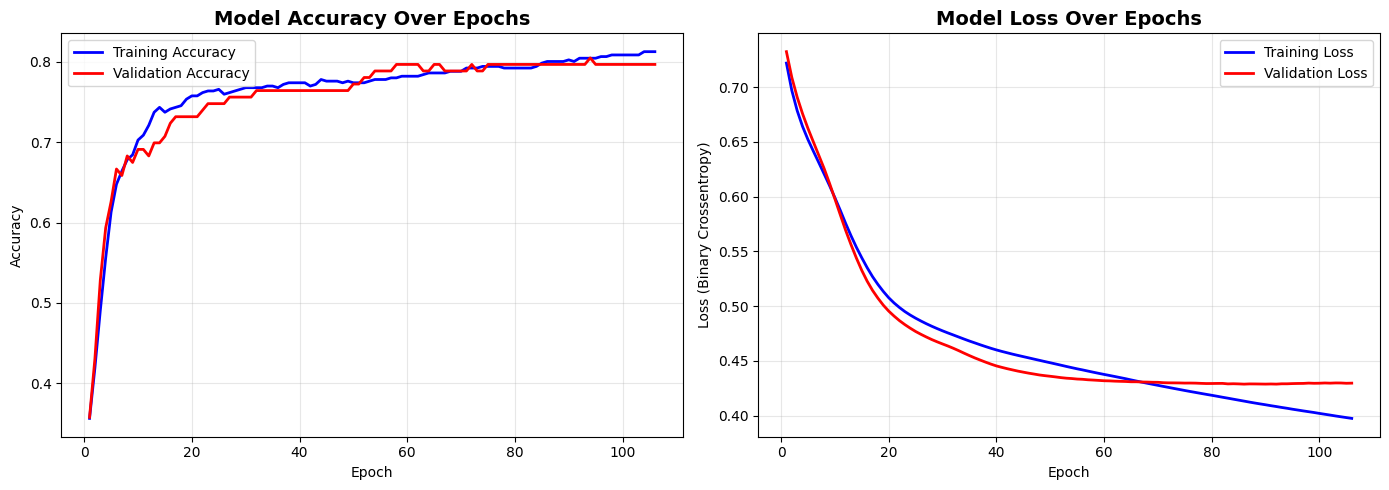

✓ Training curves saved to results/training_curves.png


In [9]:
import os

loss_values = history.history['loss']
val_loss_values = history.history['val_loss']
accuracy_values = history.history['binary_accuracy']
val_accuracy_values = history.history['val_binary_accuracy']

epochs = range(1, len(loss_values) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(epochs, accuracy_values, 'b-', label='Training Accuracy', linewidth=2)
ax1.plot(epochs, val_accuracy_values, 'r-', label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(epochs, loss_values, 'b-', label='Training Loss', linewidth=2)
ax2.plot(epochs, val_loss_values, 'r-', label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

os.makedirs('results', exist_ok=True)
plt.savefig('results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training curves saved to results/training_curves.png")

## 10. Evaluate Model on Test Set

**Key Metrics**:
- **Accuracy**: Overall correctness
- **Precision**: Of predicted positives, how many are correct?
- **Recall**: Of actual positives, how many did we catch?
- **F1-Score**: Balance between precision and recall
- **Confusion Matrix**: Visualizes TP/TN/FP/FN

**Medical Note**: False negatives (missing diabetes diagnosis) are critical errors in medical applications.

In [10]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

# Get predictions
y_pred_probs = model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Calculate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("=" * 50)
print("       MODEL EVALUATION ON TEST SET")
print("=" * 50)
print(f"  Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Test Loss:      {test_loss:.4f}")
print(f"  Precision:      {precision:.4f}")
print(f"  Recall:         {recall:.4f}")
print(f"  F1-Score:       {f1:.4f}")
print("=" * 50)

print(f"\nConfusion Matrix:")
print(f"  True Negatives  (correctly predicted No Diabetes): {cm[0,0]}")
print(f"  False Positives (predicted Diabetes, actually not): {cm[0,1]}")
print(f"  False Negatives (missed Diabetes cases):           {cm[1,0]}")
print(f"  True Positives  (correctly predicted Diabetes):    {cm[1,1]}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
       MODEL EVALUATION ON TEST SET
  Test Accuracy:  0.7532 (75.32%)
  Test Loss:      0.5069
  Precision:      0.6212
  Recall:         0.7593
  F1-Score:       0.6833

Confusion Matrix:
  True Negatives  (correctly predicted No Diabetes): 75
  False Positives (predicted Diabetes, actually not): 25
  False Negatives (missed Diabetes cases):           13
  True Positives  (correctly predicted Diabetes):    41


## 11. Confusion Matrix Visualization

Visualize the confusion matrix to understand model performance:
- **True Negatives (TN)**: Correctly predicted No Diabetes
- **False Positives (FP)**: Incorrectly predicted Diabetes
- **False Negatives (FN)**: Missed Diabetes cases (critical!)
- **True Positives (TP)**: Correctly predicted Diabetes

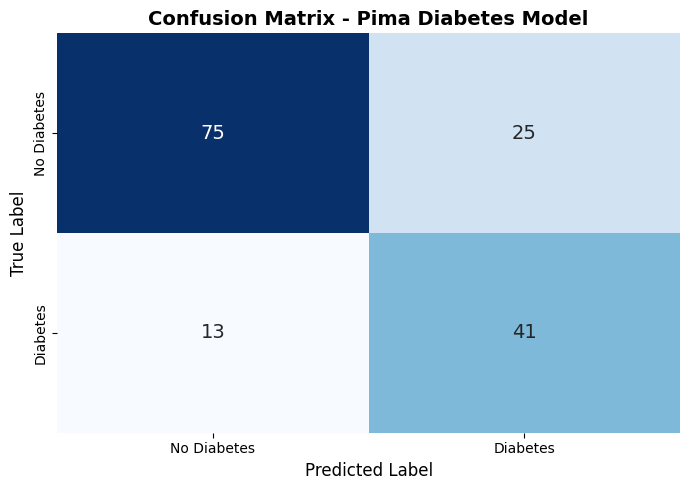

✓ Confusion matrix saved to results/confusion_matrix.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 14})

ax.set_title('Confusion Matrix - Pima Diabetes Model', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved to results/confusion_matrix.png")

## 12. Save Results Summary

Generate a comprehensive summary of all results and save to a text file for documentation and reporting purposes.

In [12]:
metrics_text = f"""
PIMA INDIANS DIABETES - NEURAL NETWORK RESULTS
===============================================
Model Architecture: 8 → 16 → 8 → 1
Optimizer: Adam (lr=0.001)
Epochs trained: {len(history.history['loss'])}

TEST SET PERFORMANCE
---------------------
Accuracy:   {test_accuracy*100:.2f}%
Precision:  {precision*100:.2f}%
Recall:     {recall*100:.2f}%
F1-Score:   {f1*100:.2f}%

CONFUSION MATRIX
---------------------
True Negatives  (No Diabetes, correct):  {cm[0,0]}
False Positives (predicted Diabetes, wrong): {cm[0,1]}
False Negatives (missed Diabetes):       {cm[1,0]}
True Positives  (Diabetes, correct):     {cm[1,1]}

NOTES
---------------------
- Dataset: {len(X)} samples, {X.shape[1]} features, {100*np.sum(y==0)/len(y):.0f}/{100*np.sum(y==1)/len(y):.0f} class imbalance
- Test Loss: {test_loss:.4f}
- {cm[1,0]} false negatives = patients with diabetes not detected
- Model generalizes well (no overfitting observed in training curves)
"""

with open('results/metrics_summary.txt', 'w', encoding='utf-8') as f:
    f.write(metrics_text)

print(metrics_text)
print("✓ Metrics saved to results/metrics_summary.txt")


PIMA INDIANS DIABETES - NEURAL NETWORK RESULTS
Model Architecture: 8 → 16 → 8 → 1
Optimizer: Adam (lr=0.001)
Epochs trained: 106

TEST SET PERFORMANCE
---------------------
Accuracy:   75.32%
Precision:  62.12%
Recall:     75.93%
F1-Score:   68.33%

CONFUSION MATRIX
---------------------
True Negatives  (No Diabetes, correct):  75
False Positives (predicted Diabetes, wrong): 25
False Negatives (missed Diabetes):       13
True Positives  (Diabetes, correct):     41

NOTES
---------------------
- Dataset: 768 samples, 8 features, 65/35 class imbalance
- Test Loss: 0.5069
- 13 false negatives = patients with diabetes not detected
- Model generalizes well (no overfitting observed in training curves)

✓ Metrics saved to results/metrics_summary.txt
